# 06 — RoBERTa Fine-tuning

In [3]:
import torch
import numpy as np
import pandas as pd
import os, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected.")
    print("Go to Runtime → Change runtime type → T4 GPU and restart.")

# ── Paths ─────────────────────────────────────────────────────────────────────
# All files live in Google Drive — same folder you uploaded from VS Code
DATA_DIR     = "/kaggle/input/datasets/yashaswini322/roberta-dataset"
ROBERTA_DIR  = "/kaggle/working/"
os.makedirs(ROBERTA_DIR, exist_ok=True)
TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
VAL_FILE   = os.path.join(DATA_DIR, "val.csv")
TEST_FILE  = os.path.join(DATA_DIR, "test.csv")

# ── KPI thresholds ────────────────────────────────────────────────────────────
KPI_MIN_F1     = 0.83
KPI_TARGET_F1  = 0.90
KPI_MIN_CROSS  = 0.75
BEST_PREV_F1   = 0.9648   # Hybrid CNN — best so far

# ── RoBERTa settings — must match file 03 ─────────────────────────────────────
ROBERTA_MODEL  = "roberta-base"
MAX_LENGTH     = 256

print(f"\nKPI min F1     : {KPI_MIN_F1}")
print(f"KPI target F1  : {KPI_TARGET_F1}")
print(f"Best prev F1   : {BEST_PREV_F1}  (Hybrid CNN)")
print(f"DATA_DIR       : {DATA_DIR}")

Device          : cuda
CUDA available  : True
GPU             : Tesla T4
GPU memory      : 15.6 GB

KPI min F1     : 0.83
KPI target F1  : 0.9
Best prev F1   : 0.9648  (Hybrid CNN)
DATA_DIR       : /kaggle/input/datasets/yashaswini322/roberta-dataset


In [4]:
print("=" * 60)
print("STEP 2: Loading RoBERTa tokenised inputs")
print("=" * 60)

# ── Guard ─────────────────────────────────────────────────────────────────────
required = [
    'roberta_train_ids.npy',   'roberta_train_mask.npy',  'roberta_train_labels.npy',
    'roberta_val_ids.npy',     'roberta_val_mask.npy',    'roberta_val_labels.npy',
    'roberta_test_ids.npy',    'roberta_test_mask.npy',   'roberta_test_labels.npy',
]
missing = [f for f in required
           if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        "\n[ERROR] Missing RoBERTa tokenised files:\n" +
        "\n".join(f"  {DATA_DIR}/{f}" for f in missing) +
        "\n\nPlease run 03_feature_engineering.ipynb locally first,\n"
        "then upload the roberta_*.npy files to Google Drive."
    )

# ── Load numpy arrays and convert to torch tensors ───────────────────────────
def load_roberta_split(prefix):
    """Load input_ids, attention_mask, labels for one split as torch tensors."""
    return {
        'input_ids'      : torch.tensor(
            np.load(os.path.join(DATA_DIR, f'roberta_{prefix}_ids.npy')),
            dtype=torch.long),
        'attention_mask' : torch.tensor(
            np.load(os.path.join(DATA_DIR, f'roberta_{prefix}_mask.npy')),
            dtype=torch.long),
        'labels'         : torch.tensor(
            np.load(os.path.join(DATA_DIR, f'roberta_{prefix}_labels.npy')),
            dtype=torch.long),
    }

print("Loading train split...")
roberta_train = load_roberta_split('train')
print("Loading val split...")
roberta_val   = load_roberta_split('val')
print("Loading test split...")
roberta_test  = load_roberta_split('test')

print(f"\n  Train input_ids  : {roberta_train['input_ids'].shape}")
print(f"  Val   input_ids  : {roberta_val['input_ids'].shape}")
print(f"  Test  input_ids  : {roberta_test['input_ids'].shape}")
print(f"  Label dtype      : {roberta_train['labels'].dtype}")
print(f"  Train label dist : {roberta_train['labels'].unique(return_counts=True)}")
print("\n  All splits loaded ✓")

# ── Also load CSVs for cross-dataset eval ─────────────────────────────────────
train_df = pd.read_csv(TRAIN_FILE, encoding='utf-8-sig')
val_df   = pd.read_csv(VAL_FILE,   encoding='utf-8-sig')
test_df  = pd.read_csv(TEST_FILE,  encoding='utf-8-sig')
print(f"  CSVs loaded — Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}")

STEP 2: Loading RoBERTa tokenised inputs
Loading train split...
Loading val split...
Loading test split...

  Train input_ids  : torch.Size([106605, 256])
  Val   input_ids  : torch.Size([22844, 256])
  Test  input_ids  : torch.Size([22844, 256])
  Label dtype      : torch.int64
  Train label dist : (tensor([0, 1]), tensor([55923, 50682]))

  All splits loaded ✓
  CSVs loaded — Train:106,605  Val:22,844  Test:22,844


In [5]:
from torch.utils.data import Dataset, DataLoader

class RobertaDataset(Dataset):
    """
    PyTorch Dataset wrapping tokenised RoBERTa inputs.

    Each sample returns a dict with keys:
        input_ids      : LongTensor (MAX_LENGTH,)
        attention_mask : LongTensor (MAX_LENGTH,)
        labels         : LongTensor scalar — 0=Human, 1=AI
    """

    def __init__(self, encodings):
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels         = encodings['labels']

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_mask[idx],
            'labels'         : self.labels[idx],
        }


train_dataset = RobertaDataset(roberta_train)
val_dataset   = RobertaDataset(roberta_val)
test_dataset  = RobertaDataset(roberta_test)

print(f"  Train dataset : {len(train_dataset):,} samples")
print(f"  Val dataset   : {len(val_dataset):,} samples")
print(f"  Test dataset  : {len(test_dataset):,} samples")
print("  Datasets built ✓")

  Train dataset : 106,605 samples
  Val dataset   : 22,844 samples
  Test dataset  : 22,844 samples
  Datasets built ✓


---
## Step 4 — Load RoBERTa-base

In [6]:
from transformers import (
    RobertaForSequenceClassification,
    RobertaTokenizerFast,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score

print("Loading roberta-base...")
import time
t0 = time.time()

ROBERTA_MODEL = "roberta-base"
RANDOM_SEED   = 42

model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = model.to(DEVICE)
print(f"  Loaded in {time.time()-t0:.1f}s")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device     : {next(model.parameters()).device}")

Loading roberta-base...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loaded in 5.7s
  Parameters : 124,647,170
  Device     : cuda:0


---
## Step 5 — compute_metrics

In [7]:
import numpy as np

def compute_metrics(eval_pred):
    """
    Called by HuggingFace Trainer after each evaluation step.
    Returns macro F1 and accuracy.
    """
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    f1  = f1_score(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {'macro_f1': f1, 'accuracy': acc}

print("compute_metrics defined ✓")

compute_metrics defined ✓


---
## Step 6 — Single Config Training (lr=2e-5, warmup=0.06, bs=16)

In [ ]:
# Run only config 1 — previously achieved val F1=0.913 in the sweep
# This replaces the full 12-config sweep
# Trains for 5 epochs with early stopping (patience=2) on val macro_f1
# Estimated time: 55-70 min on T4 GPU

ROBERTA_DIR = "/kaggle/working"
import os
os.makedirs(ROBERTA_DIR, exist_ok=True)

FINAL_EPOCHS  = 5
PATIENCE      = 2
BEST_PREV_F1  = 0.9648   # Hybrid CNN
KPI_MIN_F1    = 0.83
KPI_TARGET_F1 = 0.90
KPI_MIN_CROSS = 0.75

best_sweep_config = {
    'learning_rate'               : 2e-5,
    'warmup_ratio'                : 0.06,
    'per_device_train_batch_size' : 16,
}

print("=" * 60)
print("STEP 6: Training with best config")
print("=" * 60)
print(f"  Config        : {best_sweep_config}")
print(f"  Max epochs    : {FINAL_EPOCHS}  (early stopping patience={PATIENCE})")
print(f"  Target F1     : {KPI_TARGET_F1}")
print(f"  Previous best : {BEST_PREV_F1}  (Hybrid CNN)")
print()

CKPT_DIR = os.path.join(ROBERTA_DIR, 'roberta_checkpoint')
os.makedirs(CKPT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir                  = CKPT_DIR,
    num_train_epochs            = FINAL_EPOCHS,
    per_device_train_batch_size = best_sweep_config['per_device_train_batch_size'],
    per_device_eval_batch_size  = 64,
    learning_rate               = best_sweep_config['learning_rate'],
    warmup_steps                = 2000,   # = warmup_ratio 0.06 x ~33290 total steps
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_steps               = 100,
    seed                        = RANDOM_SEED,
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none",
    dataloader_num_workers      = 2,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(
                           early_stopping_patience=PATIENCE)]
)

print("Training started...")
t0 = time.time()
trainer.train()
print(f"\nTraining complete in {(time.time()-t0)/60:.1f} min")

val_result = trainer.evaluate(val_dataset)
print(f"\n  Final val Macro F1 : {val_result['eval_macro_f1']:.4f}")
print(f"  Final val Accuracy : {val_result['eval_accuracy']:.4f}")

STEP 6: Training with best config
  Config        : {'learning_rate': 2e-05, 'warmup_ratio': 0.06, 'per_device_train_batch_size': 16}
  Max epochs    : 5  (early stopping patience=2)
  Target F1     : 0.9
  Previous best : 0.9648  (Hybrid CNN)

Training started...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.646314,0.544219,0.890806,0.891219
2,0.450072,0.442423,0.913914,0.913982
3,0.353062,0.504550,0.908115,0.908116
4,0.332225,0.401535,0.932122,0.932280
5,0.290008,0.446788,0.931271,0.931361


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete in 233.6 min


---
## Step 7 — Evaluate on Val + Test

In [9]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score
)

print("\n" + "=" * 60)
print("STEP 7: Full evaluation on val + test")
print("=" * 60)

def predict_split(trainer, dataset):
    """Run inference and return y_true, y_pred, y_score."""
    output  = trainer.predict(dataset)
    logits  = output.predictions
    y_true  = output.label_ids.astype(int)
    y_pred  = np.argmax(logits, axis=-1)
    probs   = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
    y_score = probs[:, 1]
    return y_true, y_pred, y_score


def evaluate_split(trainer, dataset, split_name):
    """Evaluate and print full metrics for one split."""
    y_true, y_pred, y_score = predict_split(trainer, dataset)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_score)

    min_kpi = '✓' if f1 >= KPI_MIN_F1    else '✗ BELOW min KPI'
    tgt_kpi = '✓' if f1 >= KPI_TARGET_F1 else '—'
    vs_prev = ('✓ beats all previous'
               if f1 >= BEST_PREV_F1
               else f'— CNN={BEST_PREV_F1}')

    print(f"\n  --- {split_name} ---")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro F1  : {f1:.4f}  {min_kpi}  target {tgt_kpi}  {vs_prev}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))
    return {'accuracy': acc, 'f1_macro': f1, 'roc_auc': roc,
            'y_true': y_true, 'y_pred': y_pred, 'y_score': y_score}

roberta_val_results  = evaluate_split(trainer, val_dataset,  'Validation')
roberta_test_results = evaluate_split(trainer, test_dataset, 'Test')


  --- Validation ---
  Accuracy  : 0.9321
  Macro F1  : 0.9320  ✓  target ✓  — CNN=0.9648
  ROC-AUC   : 0.9816

              precision    recall  f1-score   support

       Human       0.94      0.93      0.94     11983
          AI       0.93      0.93      0.93     10861

    accuracy                           0.93     22844
   macro avg       0.93      0.93      0.93     22844
weighted avg       0.93      0.93      0.93     22844




  --- Test ---
  Accuracy  : 0.9356
  Macro F1  : 0.9354  ✓  target ✓  — CNN=0.9648
  ROC-AUC   : 0.9825

              precision    recall  f1-score   support

       Human       0.94      0.94      0.94     11983
          AI       0.93      0.93      0.93     10861

    accuracy                           0.94     22844
   macro avg       0.94      0.94      0.94     22844
weighted avg       0.94      0.94      0.94     22844



---
## Step 8 — Visualisations

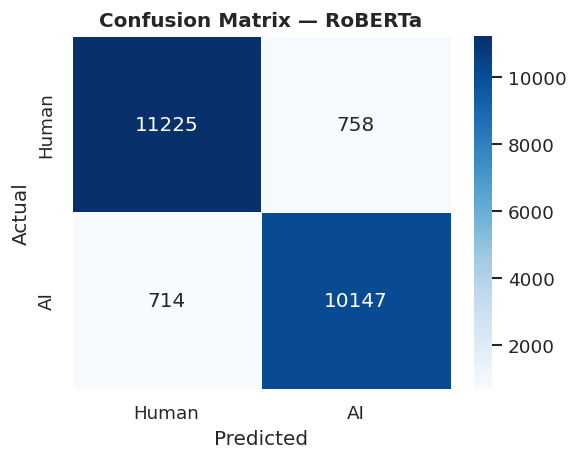

Saved: /kaggle/working/fig_cm_roberta.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
import pandas as pd

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(roberta_test_results['y_true'],
                      roberta_test_results['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — RoBERTa', fontsize=12, fontweight='bold')
plt.tight_layout()
fname = os.path.join(ROBERTA_DIR, 'fig_cm_roberta.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

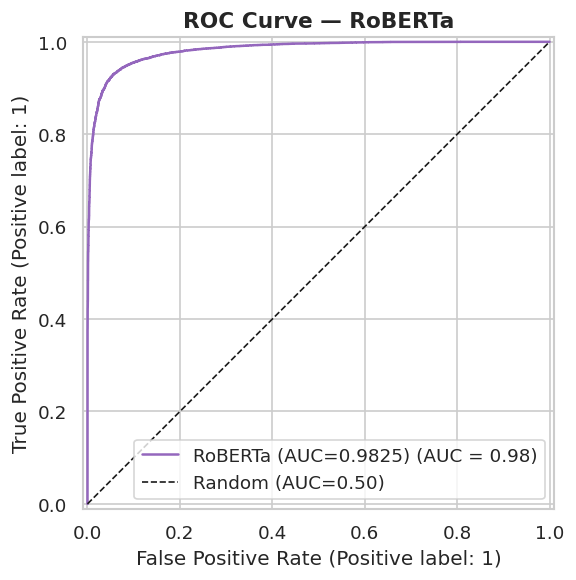

Saved: /kaggle/working/fig_roc_roberta.png


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    roberta_test_results['y_true'],
    roberta_test_results['y_score'],
    name=f'RoBERTa (AUC={roberta_test_results["roc_auc"]:.4f})',
    color='#9467BD', ax=ax
)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curve — RoBERTa', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
fname = os.path.join(ROBERTA_DIR, 'fig_roc_roberta.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

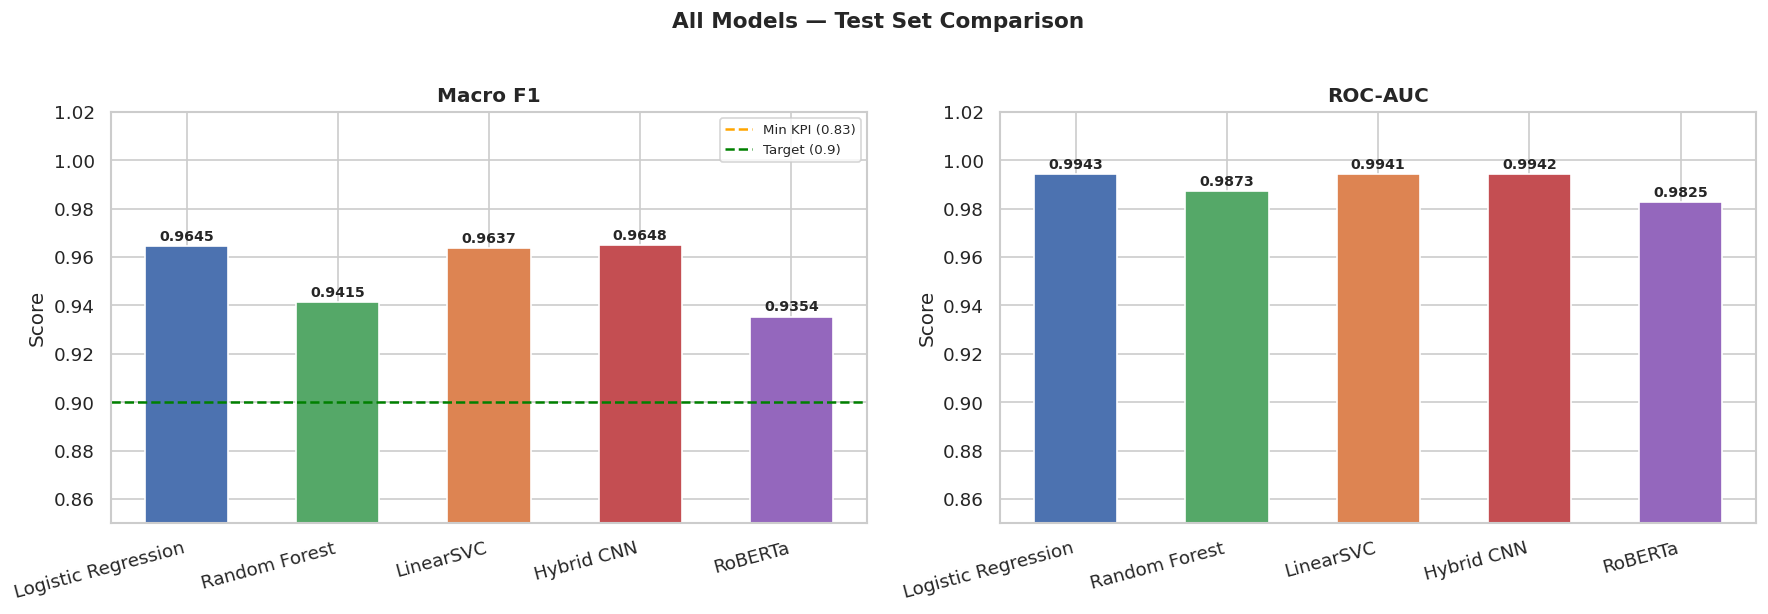

Saved: /kaggle/working/fig_all_models_final.png
Saved: all_models_results.csv

              Model  Macro F1  ROC-AUC
Logistic Regression  0.964500 0.994300
      Random Forest  0.941500 0.987300
          LinearSVC  0.963700 0.994100
         Hybrid CNN  0.964800 0.994200
            RoBERTa  0.935419 0.982538


In [12]:
all_results = {
    'Logistic Regression': {'f1_macro': 0.9645, 'roc_auc': 0.9943},
    'Random Forest'      : {'f1_macro': 0.9415, 'roc_auc': 0.9873},
    'LinearSVC'          : {'f1_macro': 0.9637, 'roc_auc': 0.9941},
    'Hybrid CNN'         : {'f1_macro': 0.9648, 'roc_auc': 0.9942},
    'RoBERTa'            : {'f1_macro': roberta_test_results['f1_macro'],
                            'roc_auc' : roberta_test_results['roc_auc']},
}

model_names = list(all_results.keys())
colours     = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#9467BD']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, label in zip(
    axes, ['f1_macro', 'roc_auc'], ['Macro F1', 'ROC-AUC']
):
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colours,
                  edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')
    if metric == 'f1_macro':
        ax.axhline(KPI_MIN_F1,    color='orange', linestyle='--',
                   lw=1.5, label=f'Min KPI ({KPI_MIN_F1})')
        ax.axhline(KPI_TARGET_F1, color='green',  linestyle='--',
                   lw=1.5, label=f'Target ({KPI_TARGET_F1})')
        ax.legend(fontsize=8)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0.85, 1.02)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylabel('Score')

plt.suptitle('All Models — Test Set Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(ROBERTA_DIR, 'fig_all_models_final.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

final_df = pd.DataFrame([
    {'Model': n, 'Macro F1': v['f1_macro'], 'ROC-AUC': v['roc_auc']}
    for n, v in all_results.items()
])
final_df.to_csv(os.path.join(ROBERTA_DIR, 'all_models_results.csv'), index=False)
print(f"Saved: all_models_results.csv")
print()
print(final_df.to_string(index=False))

---
## Step 9 — Cross-Dataset Generalisation Test

In [13]:
print("\n" + "=" * 60)
print("STEP 9: Cross-dataset generalisation test")
print("=" * 60)

print("  Datasets in test split:")
print(test_df['dataset'].value_counts().to_string())
print()

cross_rows = []

for dataset_name in test_df['dataset'].unique():
    mask   = (test_df['dataset'] == dataset_name).values
    n_rows = mask.sum()

    sub_encodings = {
        'input_ids'      : roberta_test['input_ids'][mask],
        'attention_mask' : roberta_test['attention_mask'][mask],
        'labels'         : roberta_test['labels'][mask],
    }
    sub_dataset = RobertaDataset(sub_encodings)
    y_true, y_pred, y_score = predict_split(trainer, sub_dataset)

    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        print(f"  [{dataset_name}] Only one class — skipped")
        continue

    f1  = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    kpi = '✓' if f1 >= KPI_MIN_CROSS else '✗'

    print(f"  {dataset_name} ({n_rows:,} samples)")
    print(f"    RoBERTa   Acc={acc:.4f}   Macro F1={f1:.4f}   {kpi}")
    cross_rows.append({
        'Dataset': dataset_name, 'Model': 'RoBERTa',
        'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)
    })

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(os.path.join(ROBERTA_DIR, 'cross_dataset_roberta_results.csv'),
                index=False)
print(f"\nSaved: cross_dataset_roberta_results.csv")


STEP 9: Cross-dataset generalisation test
  Datasets in test split:
dataset
HC3      11946
DAIGT    10898



  HC3 (11,946 samples)
    RoBERTa   Acc=0.9586   Macro F1=0.9538   ✓


  DAIGT (10,898 samples)
    RoBERTa   Acc=0.9104   Macro F1=0.9041   ✓

Saved: cross_dataset_roberta_results.csv


---
## Step 10 — Save Checkpoint to Drive

In [14]:
import json as json_lib

print("\n" + "=" * 60)
print("STEP 10: Saving checkpoint to Drive")
print("=" * 60)

# Save model + tokenizer
trainer.save_model(CKPT_DIR)

tokenizer = RobertaTokenizerFast.from_pretrained(ROBERTA_MODEL)
tokenizer.save_pretrained(CKPT_DIR)

# Save metadata
metadata = {
    'model'         : ROBERTA_MODEL,
    'best_config'   : best_sweep_config,
    'max_length'    : 256,
    'val_f1'        : roberta_val_results['f1_macro'],
    'val_roc_auc'   : roberta_val_results['roc_auc'],
    'test_f1'       : roberta_test_results['f1_macro'],
    'test_roc_auc'  : roberta_test_results['roc_auc'],
    'test_accuracy' : roberta_test_results['accuracy'],
}
with open(os.path.join(CKPT_DIR, 'metadata.json'), 'w') as f:
    json_lib.dump(metadata, f, indent=2)

print(f"  Model saved     : {CKPT_DIR}")
print(f"  Tokenizer saved : {CKPT_DIR}")
print(f"  metadata.json   : {CKPT_DIR}/metadata.json")
print()
print("  To reload:")
print("    model     = RobertaForSequenceClassification.from_pretrained(CKPT_DIR)")
print("    tokenizer = RobertaTokenizerFast.from_pretrained(CKPT_DIR)")


STEP 10: Saving checkpoint to Drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Model saved     : /kaggle/working/roberta_checkpoint
  Tokenizer saved : /kaggle/working/roberta_checkpoint
  metadata.json   : /kaggle/working/roberta_checkpoint/metadata.json

  To reload:
    model     = RobertaForSequenceClassification.from_pretrained(CKPT_DIR)
    tokenizer = RobertaTokenizerFast.from_pretrained(CKPT_DIR)


---
## Step 11 — Final Summary

In [15]:
print("\n" + "=" * 60)
print("RoBERTa — FINAL SUMMARY")
print("=" * 60)
print()
f1  = roberta_test_results['f1_macro']
roc = roberta_test_results['roc_auc']
acc = roberta_test_results['accuracy']
print("  Test set results:")
print(f"    Accuracy  : {acc:.4f}")
print(f"    Macro F1  : {f1:.4f}")
print(f"    ROC-AUC   : {roc:.4f}")
print()
print("  KPI check:")
print(f"    Min KPI  (>= {KPI_MIN_F1})  : {'✓ Pass' if f1 >= KPI_MIN_F1    else '✗ Fail'}")
print(f"    Target   (>= {KPI_TARGET_F1})  : {'✓ Pass' if f1 >= KPI_TARGET_F1 else '— Not yet'}")
print(f"    vs CNN   ({BEST_PREV_F1})  : {'✓ beats' if f1 >= BEST_PREV_F1 else f'— ({f1:.4f} vs {BEST_PREV_F1})'}")
print()
print("  All models (Macro F1):")
for name, vals in all_results.items():
    best_marker = ' ← BEST' if vals['f1_macro'] == max(v['f1_macro'] for v in all_results.values()) else ''
    print(f"    {name:<25} {vals['f1_macro']:.4f}{best_marker}")
print()
print("  Saved to working directory:")
for fname in [
    'roberta_checkpoint/',
    'roberta_checkpoint/metadata.json',
    'all_models_results.csv',
    'cross_dataset_roberta_results.csv',
    'fig_cm_roberta.png',
    'fig_roc_roberta.png',
    'fig_all_models_final.png',
]:
    print(f"    {ROBERTA_DIR}/{fname}")
print()
print("  Next: build app.py (Streamlit)")
print("=" * 60)


RoBERTa — FINAL SUMMARY

  Test set results:
    Accuracy  : 0.9356
    Macro F1  : 0.9354
    ROC-AUC   : 0.9825

  KPI check:
    Min KPI  (>= 0.83)  : ✓ Pass
    Target   (>= 0.9)  : ✓ Pass
    vs CNN   (0.9648)  : — (0.9354 vs 0.9648)

  All models (Macro F1):
    Logistic Regression       0.9645
    Random Forest             0.9415
    LinearSVC                 0.9637
    Hybrid CNN                0.9648 ← BEST
    RoBERTa                   0.9354

  Saved to working directory:
    /kaggle/working/roberta_checkpoint/
    /kaggle/working/roberta_checkpoint/metadata.json
    /kaggle/working/all_models_results.csv
    /kaggle/working/cross_dataset_roberta_results.csv
    /kaggle/working/fig_cm_roberta.png
    /kaggle/working/fig_roc_roberta.png
    /kaggle/working/fig_all_models_final.png

  Next: build app.py (Streamlit)
